In [12]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# import pandas as pd
# import numpy as np

# # =========================
# # 경로 설정 (비워둠)
# # =========================
# DF2_PATH = r"C:/Users/qkrtl/Downloads/df2.csv"                  # 예: r"C:\...\df2.csv"
# MASTER_PATH = r"C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/04_temp_parquet_files/analysis_output/master_all_columns.csv"               # 예: r"C:\...\master_all_columns.csv"


# # =========================
# # 조인 키 (기본: matchId + name)
# # =========================
# KEYS = ["matchId", "name"]

# # survival_time 컬럼 후보 (master에서 찾기)
# SURVIVAL_CANDIDATES = ["survival_time", "survivalTime", "timeAlive", "TimeAlive"]
# SURVIVAL_THRESHOLD = 120  # 2분

# # =========================
# # 유틸
# # =========================
# def normalize_key_values(df: pd.DataFrame, keys):
#     out = df.copy()
#     for k in keys:
#         out[k] = out[k].astype("string").str.strip().replace("", pd.NA)
#     return out

# def pick_survival_col(df: pd.DataFrame, candidates):
#     for c in candidates:
#         if c in df.columns:
#             return c
#     return None

# # =========================
# # 1) 로드
# # =========================
# df2 = pd.read_csv(DF2_PATH, low_memory=False)
# master = pd.read_csv(MASTER_PATH, low_memory=False)

# # 키 존재 체크
# for k in KEYS:
#     if k not in df2.columns:
#         raise KeyError(f"df2에 키 컬럼이 없습니다: {k}")
#     if k not in master.columns:
#         raise KeyError(f"master_all_columns에 키 컬럼이 없습니다: {k}")

# # 키 정규화(공백/타입)
# df2_n = normalize_key_values(df2, KEYS)
# master_n = normalize_key_values(master, KEYS)

# # =========================
# # 2) master 쪽 중복키 처리 (중요)
# #    - left join에서 master에 같은 키가 여러 개면 df2 행이 증식함
# # =========================
# dup_master = master_n.duplicated(KEYS).sum()
# print(f"[master] duplicated keys rows = {dup_master:,}")

# if dup_master > 0:
#     # 기본 정책: 같은 키면 "첫 번째"만 사용
#     # (원하면 '마지막' 또는 특정 컬럼 기준 정렬 후 drop_duplicates로 바꿔도 됨)
#     master_n = master_n.drop_duplicates(KEYS, keep="first").copy()
#     print(f"[master] after dedup, rows = {len(master_n):,}")

# # =========================
# # 3) df2 기준 LEFT JOIN
# #    - 겹치는 컬럼명은 _df2 / _master suffix로 구분
# # =========================
# merged = df2_n.merge(
#     master_n,
#     on=KEYS,
#     how="left",
#     suffixes=("_df2", "_master"),
#     indicator=True,            # 매칭 여부 확인용
#     validate="m:1"             # df2 many : master one (dedup 했으므로 이게 정상)
# )

# # =========================
# # 4) 매칭 리포트
# # =========================
# vc = merged["_merge"].value_counts(dropna=False)
# print("\n[JOIN 결과 _merge 카운트]")
# print(vc.to_string())

# match_rate = (merged["_merge"] == "both").mean()
# print(f"\n[JOIN 매칭률] {match_rate:.2%} (df2 기준)")

# # =========================
# # 5) survival_time 기반 플래그 컬럼 생성 (필터 대신 컬럼으로 관리)
# # =========================
# surv_col = pick_survival_col(merged, SURVIVAL_CANDIDATES)
# print(f"\n[사용 survival 컬럼] {surv_col}")

# if surv_col is not None:
#     merged[surv_col] = pd.to_numeric(merged[surv_col], errors="coerce")
#     merged["is_2min_over"] = merged[surv_col].ge(SURVIVAL_THRESHOLD)
#     merged["is_2min_under"] = merged[surv_col].lt(SURVIVAL_THRESHOLD)
#     merged["survival_is_na"] = merged[surv_col].isna()
# else:
#     # master에서 survival_time이 안 붙은 경우(매칭 실패 포함) 대비
#     merged["is_2min_over"] = pd.NA
#     merged["is_2min_under"] = pd.NA
#     merged["survival_is_na"] = pd.NA

# # =========================
# # 6) 필요하면 indicator 컬럼 제거
# # =========================
# # merged = merged.drop(columns=["_merge"])

# # =========================
# # 7) 저장(원하면)
# # =========================
# OUT_PATH = r"C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/04_temp_parquet_files/analysis_output/master.csv" 
# merged.to_csv(OUT_PATH, index=False)
# print("\n완료: df2 LEFT JOIN master_all_columns + is_2min_over 생성")


[master] duplicated keys rows = 28,045
[master] after dedup, rows = 823,389

[JOIN 결과 _merge 카운트]
_merge
both          821596
left_only       6505
right_only         0

[JOIN 매칭률] 99.21% (df2 기준)

[사용 survival 컬럼] survival_time

완료: df2 LEFT JOIN master_all_columns + is_2min_over 생성


In [6]:
df = pd.read_csv("C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/04_temp_parquet_files/analysis_output/master.csv")
df.head()


,matchId,mapName_df2,gameMode_df2,createdAt_df2,DBNOs_df2,assists_df2,boosts,damageDealt,deathType_df2,headshotKills_df2,...,weaponsAcquired_master,winPlace_df2,servername_master,currentRankPoint_master,game_type_master,tier_master,_merge,is_2min_over,is_2min_under,survival_is_na
0,6f3b4b92-5c17-4a7e-a8b0-4a35ad7c1d7a,Desert_Main,squad,2026-02-15 18:31:26+00:00,2,0,0,200.00000,byplayer,0,...,8.0,18.0,steam,801.0,official,Bronze,both,True,False,False
1,fcf230a3-e9bd-4c7e-a5ac-28e998a499d5,Desert_Main,squad,2026-02-19 06:03:34+00:00,2,0,3,203.72414,byplayer,2,...,9.0,10.0,steam,1910.0,competitive,Gold,both,True,False,False
2,d76c3295-4742-467e-9d86-c58edfebcdcf,Neon_Main,squad,2026-02-11 20:02:02+00:00,1,4,6,451.97598,byplayer,2,...,10.0,7.0,steam,0.0,official,Unranked,both,True,False,False
3,58878e90-c3c3-4be9-bd42-268f3a7ee3e2,Tiger_Main,squad,2026-02-11 22:08:41+00:00,2,1,5,382.21080,byplayer,0,...,13.0,4.0,steam,0.0,official,Unranked,both,True,False,False
4,4bad3d1a-2bf0-4921-8b14-50984cbdf2eb,Baltic_Main,squad,2026-02-16 14:36:19+00:00,3,0,7,428.00513,byplayer,1,...,16.0,8.0,steam,0.0,official,Unranked,both,True,False,False


In [7]:
df.shape

(828101, 101)

In [10]:
df2 = pd.read_csv("C:/Users/qkrtl/Downloads/df2.csv")

erangel = pd.read_parquet("C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/04_temp_parquet_files/analysis_output/erangel_clustered.parquet")
miramar = pd.read_parquet("C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/04_temp_parquet_files/analysis_output/miramar_clustered.parquet")
rondo   = pd.read_parquet("C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/04_temp_parquet_files/analysis_output/rondo_clustered.parquet")
taego   = pd.read_parquet("C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/04_temp_parquet_files/analysis_output/taego_clustered.parquet")

clustered_df = pd.concat([erangel, miramar, rondo, taego], ignore_index=True)

merged = pd.merge(
    df2,
    clustered_df,
    left_on=["matchId", "playerId"],
    right_on=["matchId", "accountId"],
    how="left"
)

In [11]:
merged.to_csv("master.csv")

In [13]:
merged.shape

(828101, 68)

In [15]:
merged.T

,0,1,2,3,4,5,6,7,8,9,...,828091,828092,828093,828094,828095,828096,828097,828098,828099,828100
matchId,6f3b4b92-5c17-4a7e-a8b0-4a35ad7c1d7a,fcf230a3-e9bd-4c7e-a5ac-28e998a499d5,d76c3295-4742-467e-9d86-c58edfebcdcf,58878e90-c3c3-4be9-bd42-268f3a7ee3e2,4bad3d1a-2bf0-4921-8b14-50984cbdf2eb,af957311-c148-4b8d-9708-396ec41f9dd9,51656ac0-1e85-419d-ac1e-27287c81995c,6f6c31c7-63be-416b-95dd-42d89dffccdc,5bbf91fc-6cac-4d42-89f2-de11c4e6d28a,9c1beb47-6956-491d-9907-d982ee65a478,...,220d4efc-5604-40f0-ba7a-3b2b855ee245,acdfc4e4-e657-4c4f-859b-5c2e8546933e,f5de6cff-df82-4097-bb9f-a39d1bb20176,66da2633-4bab-4bd5-92cd-9ad73098acbb,a5b37d26-e679-4f70-8912-dbc0c9e72896,5c29f5c3-d0ea-457d-b2b8-0f78df6a0ada,29e661b4-f8d1-4d57-b1d3-2dd44753a752,60e703c6-589a-4a67-85f3-b5a31ade82ed,0371162c-d278-4ad2-8fc1-f07985991e72,e9588a80-5c13-4e22-8496-90bc9429c928
mapName,Desert_Main,Desert_Main,Neon_Main,Tiger_Main,Baltic_Main,Tiger_Main,Tiger_Main,Tiger_Main,Tiger_Main,Neon_Main,...,Neon_Main,Tiger_Main,Tiger_Main,Tiger_Main,Tiger_Main,Tiger_Main,Baltic_Main,Neon_Main,Baltic_Main,Tiger_Main
gameMode,squad,squad,squad,squad,squad,squad,squad,squad,squad-fpp,squad-fpp,...,squad,squad,squad,squad,squad,squad,squad,squad,squad,squad
createdAt,2026-02-15 18:31:26+00:00,2026-02-19 06:03:34+00:00,2026-02-11 20:02:02+00:00,2026-02-11 22:08:41+00:00,2026-02-16 14:36:19+00:00,2026-02-12 15:45:04+00:00,2026-02-17 06:20:29+00:00,2026-02-24 13:43:01+00:00,2026-02-17 00:13:08+00:00,2026-02-17 00:35:17+00:00,...,2026-02-14 02:40:42+00:00,2026-02-24 20:35:45+00:00,2026-02-13 14:59:13+00:00,2026-02-17 11:41:45+00:00,2026-02-19 14:11:23+00:00,2026-02-19 01:42:21+00:00,2026-02-24 12:23:16+00:00,2026-02-13 13:53:48+00:00,2026-02-13 06:27:49+00:00,2026-02-20 13:29:16+00:00
DBNOs,2,2,1,2,3,4,4,1,0,3,...,4,0,0,0,2,2,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
score_C2_aggro,0.336165,2.101374,2.508123,3.668261,-0.045901,-0.456073,0.596656,2.901525,0.322327,-0.869627,...,0.57705,-0.306039,-0.107261,0.927659,-1.216028,0.046296,1.199585,2.209888,7.872853,0.720648
score_C3_guerilla,-1.645525,-0.960831,-1.776159,0.168623,1.682772,0.533029,1.913537,-0.590179,-1.686227,-0.687904,...,2.067349,-0.252934,-0.244331,0.0,1.715904,-0.216918,-1.319399,-1.011736,-3.035208,1.28
umap_x,NaN,NaN,NaN,NaN,-1.380472,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.168689,NaN,0.116763,NaN
umap_y,NaN,NaN,NaN,NaN,9.474584,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,16.354538,NaN,-0.236922,NaN


In [16]:
merged['persona']

0          🏃 중앙 점령형
1         ⚔️ 중앙 교전형
2         ⚔️ 중앙 교전형
3         ⚔️ 중앙 교전형
4         🦅 게릴라 운영형
            ...    
828096     🌿 외곽 운영형
828097     🏃 중앙 점령형
828098    ⚔️ 중앙 교전형
828099    ⚔️ 중앙 교전형
828100    🦅 게릴라 운영형
Name: persona, Length: 828101, dtype: str

In [19]:
merged['persona'].unique()

<ArrowStringArray>
['🏃 중앙 점령형', '⚔️ 중앙 교전형', '🦅 게릴라 운영형', '🌿 외곽 운영형', '❓ 혼합형', nan]
Length: 6, dtype: str

In [21]:
merged.describe()

,DBNOs,assists,boosts_x,damageDealt_x,headshotKills,heals_x,killPlace,killStreaks,kills_x,longestKill,...,move_speed,heal_boost_use,margin,score_C0_center,score_C1_edge,score_C2_aggro,score_C3_guerilla,umap_x,umap_y,margin_threshold
count,828101.000000,828101.000000,828101.000000,828101.000000,828101.000000,828101.000000,828101.000000,828101.000000,828101.000000,828101.000000,...,821596.000000,821596.000000,821596.000000,821596.000000,821596.000000,821596.000000,821596.000000,212283.000000,212283.000000,6.093130e+05
mean,1.057735,0.492252,3.627338,184.417603,0.256088,2.400394,35.226853,0.588997,1.016417,35.169157,...,1.973541,6.027052,1.159393,0.463658,0.219053,0.587920,-0.390829,0.459794,7.666155,2.000000e-01
std,1.415820,0.909413,3.407429,203.878250,0.596276,3.615120,22.259332,0.730785,1.561216,70.953750,...,0.664178,5.938032,93.717876,1.427078,93.745348,1.770636,1.816401,3.374259,4.844881,2.775560e-17
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-8.204323,-9.089759,-3.969275,-15.766222,-5.454636,-3.729967,2.000000e-01
25%,0.000000,0.000000,0.000000,35.528084,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,...,1.580229,1.000000,0.298138,-0.168623,-1.180359,-0.604955,-1.469170,-2.073887,5.409525,2.000000e-01
50%,1.000000,0.000000,3.000000,120.883650,0.000000,1.000000,34.000000,0.000000,0.000000,0.000000,...,1.962253,4.000000,0.673603,0.337245,0.000000,0.237654,-0.469735,0.048251,8.268899,2.000000e-01
75%,2.000000,1.000000,6.000000,263.000000,0.000000,3.000000,51.000000,1.000000,1.000000,37.475050,...,2.354430,9.000000,1.204983,1.115771,1.180359,1.377016,0.630834,2.512776,10.361206,2.000000e-01
max,19.000000,13.000000,31.000000,2730.388400,11.000000,104.000000,116.000000,8.000000,22.000000,932.758670,...,5.251043,25.000000,68489.117953,9.671624,68493.313831,12.035948,6.997842,15.084366,16.934275,2.000000e-01


In [22]:
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 828101 entries, 0 to 828100
Data columns (total 68 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   matchId                  828101 non-null  str    
 1   mapName                  828101 non-null  str    
 2   gameMode                 828101 non-null  str    
 3   createdAt                828101 non-null  str    
 4   DBNOs                    828101 non-null  int64  
 5   assists                  828101 non-null  int64  
 6   boosts_x                 828101 non-null  int64  
 7   damageDealt_x            828101 non-null  float64
 8   deathType                828101 non-null  str    
 9   headshotKills            828101 non-null  int64  
 10  heals_x                  828101 non-null  int64  
 11  killPlace                828101 non-null  int64  
 12  killStreaks              828101 non-null  int64  
 13  kills_x                  828101 non-null  int64  
 14  longestKill    

[맵 분석]


In [13]:
BASE_DIR = r"C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/03_mapwise_logs_kakao+steam_20260211_20260219"   # 네 폴더 경로로 수정

In [14]:
sample_fp = os.path.join(BASE_DIR, "Erangel", "LogPlayerPosition.csv")
tmp = pd.read_csv(sample_fp, usecols=["character_isInBlueZone"])
print(tmp["character_isInBlueZone"].value_counts(dropna=False).head(20))

character_isInBlueZone
False    13397938
True       837298
Name: count, dtype: int64


In [15]:
tmp = pd.read_csv(sample_fp, usecols=["elapsedTime"])
print(tmp["elapsedTime"].head())
print(tmp["elapsedTime"].dtype)

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: elapsedTime, dtype: float64
float64


In [16]:
sample_fp = os.path.join(BASE_DIR, "Erangel", "LogPlayerPosition.csv")

tmp = pd.read_csv(sample_fp, usecols=[
    "matchId", "character_accountId", "elapsedTime"
])

tmp = tmp.rename(columns={"character_accountId": "accountId"})

one = tmp[
    (tmp["matchId"] == tmp["matchId"].iloc[0]) &
    (tmp["accountId"] == tmp["accountId"].iloc[0])
].copy()

print(one["elapsedTime"].head(20))
print(one["elapsedTime"].tail(20))

0         0.0
49        0.0
100       0.0
157       0.0
218       0.0
279       0.0
340       0.0
401       0.0
462       0.0
523       3.0
584      13.0
645      23.0
706      33.0
767      43.0
828      53.0
889      63.0
950      73.0
1011     82.0
1072     92.0
1133    102.0
Name: elapsedTime, dtype: float64
2073    259.0
2128    269.0
2183    279.0
2238    289.0
2293    299.0
2348    308.0
2402    318.0
2456    328.0
2510    338.0
2564    348.0
2618    358.0
2672    367.0
2726    377.0
2780    387.0
2834    397.0
2888    407.0
2942    416.0
2996    426.0
3050    436.0
3104    446.0
Name: elapsedTime, dtype: float64


In [17]:
print(tmp["elapsedTime"].describe())

count    1.423524e+07
mean     5.391468e+02
std      4.318415e+02
min      0.000000e+00
25%      1.670000e+02
50%      4.570000e+02
75%      8.480000e+02
max      1.969000e+03
Name: elapsedTime, dtype: float64


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = r"C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/03_mapwise_logs_kakao+steam_20260211_20260219"

def plot_path_density_heatmap_chunked(
    map_name,
    bins=200,
    chunksize=300_000,
    figsize=(10, 8)
):
    fp = os.path.join(BASE_DIR, map_name, "LogPlayerPosition.csv")

    usecols = [
        "character_location_x",
        "character_location_y",
    ]

    # 1) 먼저 x/y 범위를 알아야 고정된 bin을 만들 수 있음
    x_min, x_max = np.inf, -np.inf
    y_min, y_max = np.inf, -np.inf

    for chunk in pd.read_csv(fp, usecols=usecols, chunksize=chunksize):
        chunk["character_location_x"] = pd.to_numeric(chunk["character_location_x"], errors="coerce")
        chunk["character_location_y"] = pd.to_numeric(chunk["character_location_y"], errors="coerce")
        chunk = chunk.dropna(subset=["character_location_x", "character_location_y"])

        if chunk.empty:
            continue

        x_min = min(x_min, chunk["character_location_x"].min())
        x_max = max(x_max, chunk["character_location_x"].max())
        y_min = min(y_min, chunk["character_location_y"].min())
        y_max = max(y_max, chunk["character_location_y"].max())

    if not np.isfinite(x_min) or not np.isfinite(y_min):
        print(f"{map_name}: 유효한 x/y 데이터 없음")
        return

    # 2) 고정 bins 생성
    xedges = np.linspace(x_min, x_max, bins + 1)
    yedges = np.linspace(y_min, y_max, bins + 1)

    heatmap = np.zeros((bins, bins), dtype=np.float64)

    # 3) 다시 읽으면서 누적
    for i, chunk in enumerate(pd.read_csv(fp, usecols=usecols, chunksize=chunksize), start=1):
        chunk["character_location_x"] = pd.to_numeric(chunk["character_location_x"], errors="coerce")
        chunk["character_location_y"] = pd.to_numeric(chunk["character_location_y"], errors="coerce")
        chunk = chunk.dropna(subset=["character_location_x", "character_location_y"])

        if chunk.empty:
            continue

        h, _, _ = np.histogram2d(
            chunk["character_location_x"],
            chunk["character_location_y"],
            bins=[xedges, yedges]
        )

        heatmap += h
        print(f"[{map_name}] chunk {i} 누적 완료, rows={len(chunk):,}")

    # histogram2d는 (xbin, ybin) 구조라서 보기 좋게 transpose
    plt.figure(figsize=figsize)
    plt.imshow(
        heatmap.T,
        origin="lower",
        aspect="auto",
        extent=[x_min, x_max, y_min, y_max]
    )
    plt.colorbar(label="position count")
    plt.title(f"{map_name} - Path Density Heatmap (chunk accumulated)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


def plot_drop_heatmap_chunked(
    map_name,
    bins=150,
    chunksize=200_000,
    figsize=(10, 8)
):
    fp = os.path.join(BASE_DIR, map_name, "LogParachuteLanding.csv")

    usecols = [
        "character_location_x",
        "character_location_y",
    ]

    x_min, x_max = np.inf, -np.inf
    y_min, y_max = np.inf, -np.inf

    for chunk in pd.read_csv(fp, usecols=usecols, chunksize=chunksize):
        chunk["character_location_x"] = pd.to_numeric(chunk["character_location_x"], errors="coerce")
        chunk["character_location_y"] = pd.to_numeric(chunk["character_location_y"], errors="coerce")
        chunk = chunk.dropna(subset=["character_location_x", "character_location_y"])

        if chunk.empty:
            continue

        x_min = min(x_min, chunk["character_location_x"].min())
        x_max = max(x_max, chunk["character_location_x"].max())
        y_min = min(y_min, chunk["character_location_y"].min())
        y_max = max(y_max, chunk["character_location_y"].max())

    if not np.isfinite(x_min) or not np.isfinite(y_min):
        print(f"{map_name}: 유효한 낙하 x/y 데이터 없음")
        return

    xedges = np.linspace(x_min, x_max, bins + 1)
    yedges = np.linspace(y_min, y_max, bins + 1)

    heatmap = np.zeros((bins, bins), dtype=np.float64)

    for i, chunk in enumerate(pd.read_csv(fp, usecols=usecols, chunksize=chunksize), start=1):
        chunk["character_location_x"] = pd.to_numeric(chunk["character_location_x"], errors="coerce")
        chunk["character_location_y"] = pd.to_numeric(chunk["character_location_y"], errors="coerce")
        chunk = chunk.dropna(subset=["character_location_x", "character_location_y"])

        if chunk.empty:
            continue

        h, _, _ = np.histogram2d(
            chunk["character_location_x"],
            chunk["character_location_y"],
            bins=[xedges, yedges]
        )
        heatmap += h
        print(f"[{map_name}] drop chunk {i} 누적 완료, rows={len(chunk):,}")

    plt.figure(figsize=figsize)
    plt.imshow(
        heatmap.T,
        origin="lower",
        aspect="auto",
        extent=[x_min, x_max, y_min, y_max]
    )
    plt.colorbar(label="drop count")
    plt.title(f"{map_name} - Drop Heatmap (chunk accumulated)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

def plot_path_grid_heatmap_chunked(
    map_name,
    grid_size=100000,
    chunksize=300_000,
    figsize=(10, 8)
):
    fp = os.path.join(BASE_DIR, map_name, "LogPlayerPosition.csv")

    usecols = [
        "character_location_x",
        "character_location_y",
    ]

    grid_counter = {}

    for i, chunk in enumerate(pd.read_csv(fp, usecols=usecols, chunksize=chunksize), start=1):
        chunk["x"] = pd.to_numeric(chunk["character_location_x"], errors="coerce")
        chunk["y"] = pd.to_numeric(chunk["character_location_y"], errors="coerce")
        chunk = chunk.dropna(subset=["x", "y"])

        if chunk.empty:
            continue

        chunk["gx"] = np.floor(chunk["x"] / grid_size).astype(int)
        chunk["gy"] = np.floor(chunk["y"] / grid_size).astype(int)

        counts = chunk.groupby(["gy", "gx"]).size()

        for key, val in counts.items():
            grid_counter[key] = grid_counter.get(key, 0) + val

        print(f"[{map_name}] grid chunk {i} 누적 완료, rows={len(chunk):,}")

    if not grid_counter:
        print(f"{map_name}: grid 데이터 없음")
        return

    grid_df = pd.DataFrame(
        [(gy, gx, cnt) for (gy, gx), cnt in grid_counter.items()],
        columns=["gy", "gx", "count"]
    )

    pivot = grid_df.pivot(index="gy", columns="gx", values="count").fillna(0)

    plt.figure(figsize=figsize)
    plt.imshow(pivot.values, origin="lower", aspect="auto")
    plt.colorbar(label="path count")
    plt.title(f"{map_name} - Path Grid Heatmap (chunk accumulated)")
    plt.xlabel("grid x")
    plt.ylabel("grid y")
    plt.show()

[Erangel] chunk 1 누적 완료, rows=300,000
[Erangel] chunk 2 누적 완료, rows=300,000
[Erangel] chunk 3 누적 완료, rows=300,000
[Erangel] chunk 4 누적 완료, rows=300,000
[Erangel] chunk 5 누적 완료, rows=300,000
[Erangel] chunk 6 누적 완료, rows=300,000
[Erangel] chunk 7 누적 완료, rows=300,000
[Erangel] chunk 8 누적 완료, rows=300,000
[Erangel] chunk 9 누적 완료, rows=300,000
[Erangel] chunk 10 누적 완료, rows=300,000
[Erangel] chunk 11 누적 완료, rows=300,000
[Erangel] chunk 12 누적 완료, rows=300,000
[Erangel] chunk 13 누적 완료, rows=300,000
[Erangel] chunk 14 누적 완료, rows=300,000
[Erangel] chunk 15 누적 완료, rows=300,000
[Erangel] chunk 16 누적 완료, rows=300,000
[Erangel] chunk 17 누적 완료, rows=300,000
[Erangel] chunk 18 누적 완료, rows=300,000
[Erangel] chunk 19 누적 완료, rows=300,000
[Erangel] chunk 20 누적 완료, rows=300,000
[Erangel] chunk 21 누적 완료, rows=300,000
[Erangel] chunk 22 누적 완료, rows=300,000
[Erangel] chunk 23 누적 완료, rows=300,000
[Erangel] chunk 24 누적 완료, rows=300,000
[Erangel] chunk 25 누적 완료, rows=300,000
[Erangel] chunk 26 누적 완료, rows=300

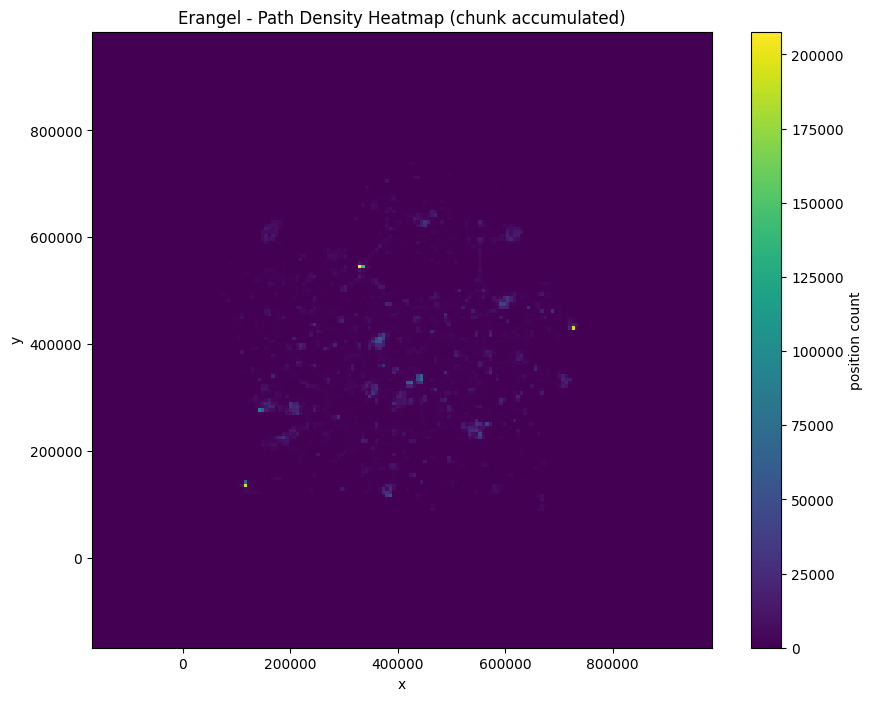

[Taego] drop chunk 1 누적 완료, rows=188,747


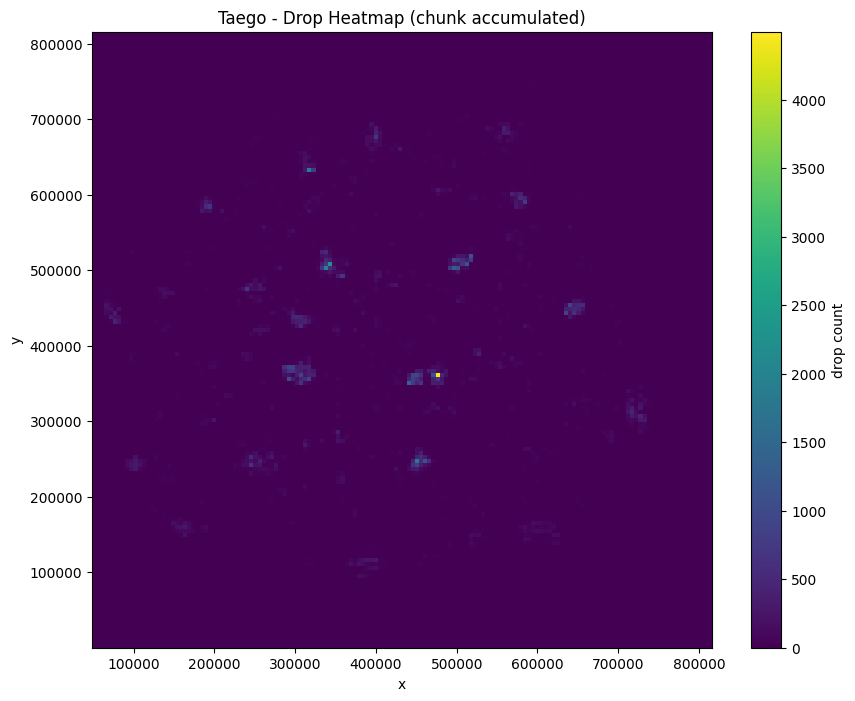

[Miramar] grid chunk 1 누적 완료, rows=300,000
[Miramar] grid chunk 2 누적 완료, rows=300,000
[Miramar] grid chunk 3 누적 완료, rows=300,000
[Miramar] grid chunk 4 누적 완료, rows=300,000
[Miramar] grid chunk 5 누적 완료, rows=300,000
[Miramar] grid chunk 6 누적 완료, rows=300,000
[Miramar] grid chunk 7 누적 완료, rows=300,000
[Miramar] grid chunk 8 누적 완료, rows=300,000
[Miramar] grid chunk 9 누적 완료, rows=300,000
[Miramar] grid chunk 10 누적 완료, rows=300,000
[Miramar] grid chunk 11 누적 완료, rows=300,000
[Miramar] grid chunk 12 누적 완료, rows=300,000
[Miramar] grid chunk 13 누적 완료, rows=300,000
[Miramar] grid chunk 14 누적 완료, rows=300,000
[Miramar] grid chunk 15 누적 완료, rows=300,000
[Miramar] grid chunk 16 누적 완료, rows=300,000
[Miramar] grid chunk 17 누적 완료, rows=300,000
[Miramar] grid chunk 18 누적 완료, rows=300,000
[Miramar] grid chunk 19 누적 완료, rows=300,000
[Miramar] grid chunk 20 누적 완료, rows=300,000
[Miramar] grid chunk 21 누적 완료, rows=300,000
[Miramar] grid chunk 22 누적 완료, rows=300,000
[Miramar] grid chunk 23 누적 완료, rows=300,0

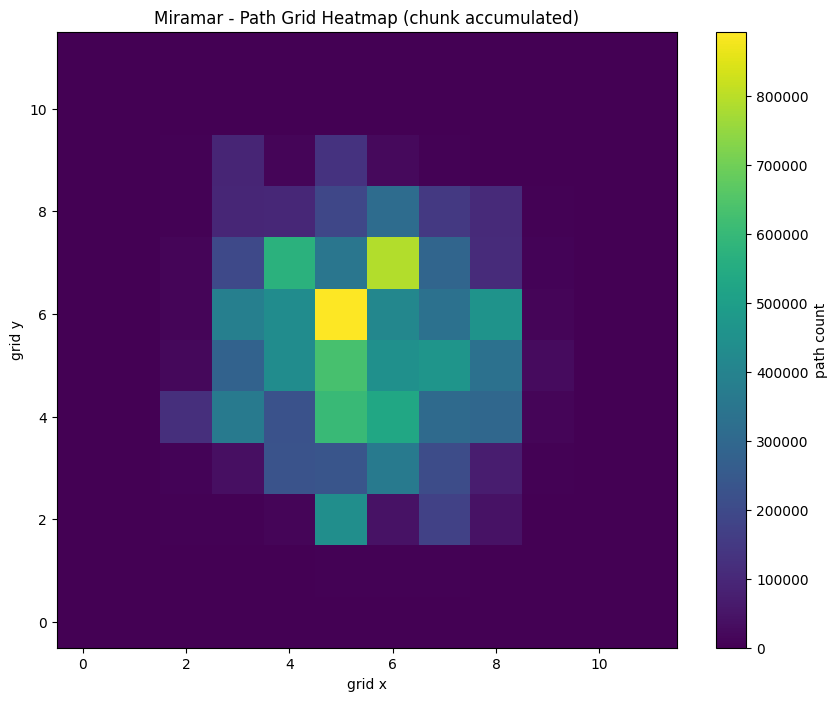

In [24]:
plot_path_density_heatmap_chunked("Erangel", bins=180, chunksize=300_000)
plot_drop_heatmap_chunked("Taego", bins=150, chunksize=200_000)
plot_path_grid_heatmap_chunked("Miramar", grid_size=100000, chunksize=300_000)

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE_DIR = r"C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/03_mapwise_logs_kakao+steam_20260211_20260219"
MAP_IMG_DIR = r"C:/Users/qkrtl/10th/00_Project/map_images"  # 맵 이미지 폴더

def plot_drop_scatter_on_map(map_name, img_filename, sample_n=5000, figsize=(10, 10)):
    csv_fp = os.path.join(BASE_DIR, map_name, "LogParachuteLanding.csv")
    img_fp = os.path.join(MAP_IMG_DIR, img_filename)

    df = pd.read_csv(csv_fp, usecols=[
        "character_location_x",
        "character_location_y"
    ])

    df = df.rename(columns={
        "character_location_x": "x",
        "character_location_y": "y"
    })

    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df = df.dropna(subset=["x", "y"])

    if len(df) > sample_n:
        df = df.sample(sample_n, random_state=42)

    img = mpimg.imread(img_fp)

    x_min, x_max = df["x"].min(), df["x"].max()
    y_min, y_max = df["y"].min(), df["y"].max()

    plt.figure(figsize=figsize)
    plt.imshow(img, extent=[0, 1000000, 0, 1000000], origin="upper")
    plt.scatter(df["x"], df["y"], s=2, alpha=0.3)
    plt.title(f"{map_name} - Drop Scatter on Map")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()



import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def plot_path_heatmap_on_map(map_name, img_filename, bins=180, chunksize=300_000, figsize=(10, 10)):
    csv_fp = os.path.join(BASE_DIR, map_name, "LogPlayerPosition.csv")
    img_fp = os.path.join(MAP_IMG_DIR, img_filename)

    usecols = ["character_location_x", "character_location_y"]

    x_min, x_max = np.inf, -np.inf
    y_min, y_max = np.inf, -np.inf

    # 1차: 범위 확인
    for chunk in pd.read_csv(csv_fp, usecols=usecols, chunksize=chunksize):
        chunk["character_location_x"] = pd.to_numeric(chunk["character_location_x"], errors="coerce")
        chunk["character_location_y"] = pd.to_numeric(chunk["character_location_y"], errors="coerce")
        chunk = chunk.dropna(subset=["character_location_x", "character_location_y"])
        if chunk.empty:
            continue

        x_min = min(x_min, chunk["character_location_x"].min())
        x_max = max(x_max, chunk["character_location_x"].max())
        y_min = min(y_min, chunk["character_location_y"].min())
        y_max = max(y_max, chunk["character_location_y"].max())

    if not np.isfinite(x_min):
        print("유효한 데이터 없음")
        return

    xedges = np.linspace(x_min, x_max, bins + 1)
    yedges = np.linspace(y_min, y_max, bins + 1)
    heatmap = np.zeros((bins, bins), dtype=np.float64)

    # 2차: 누적
    for chunk in pd.read_csv(csv_fp, usecols=usecols, chunksize=chunksize):
        chunk["character_location_x"] = pd.to_numeric(chunk["character_location_x"], errors="coerce")
        chunk["character_location_y"] = pd.to_numeric(chunk["character_location_y"], errors="coerce")
        chunk = chunk.dropna(subset=["character_location_x", "character_location_y"])
        if chunk.empty:
            continue

        h, _, _ = np.histogram2d(
            chunk["character_location_x"],
            chunk["character_location_y"],
            bins=[xedges, yedges]
        )
        heatmap += h

    img = mpimg.imread(img_fp)

    plt.figure(figsize=figsize)
    plt.imshow(img, extent=[x_min, x_max, y_min, y_max], origin="upper")
    plt.imshow(
        np.log1p(heatmap).T,
        extent=[x_min, x_max, y_min, y_max],
        origin="lower",
        cmap="gray",
        alpha=0.6,
        aspect="equal"
    )
    plt.title(f"{map_name} - Path Heatmap on Map")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

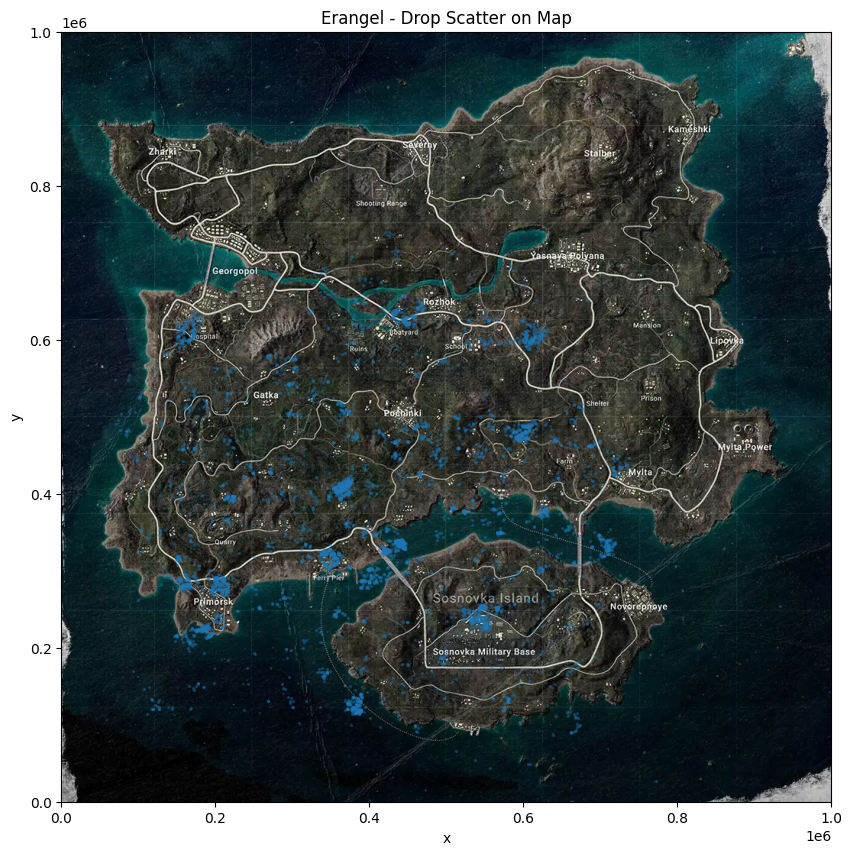

KeyboardInterrupt: 

In [ ]:
# 위 코드 실행
plot_drop_scatter_on_map("Erangel", "C:/Users/qkrtl/10th/00_Project/04_final/03_team_code/map_erangel.webp")
plot_path_heatmap_on_map("Erangel", "C:/Users/qkrtl/10th/00_Project/04_final/03_team_code/map_erangel.webp")


In [51]:
import os
import matplotlib.image as mpimg


# 에란겔, 미라마, 사녹, 태이고, 론도를 직접 경로를 넣어서
# 해당 맵의 좌표를 수기로 찍어내야 함.
MAP_IMG_DIR = r"C:/Users/qkrtl/10th/00_Project/map_images"
img_fp = os.path.join(MAP_IMG_DIR, "C:/Users/qkrtl/10th/00_Project/04_final/03_team_code/map_rondo.webp")

img = mpimg.imread(img_fp)
print(img.shape)  # (height, width, channel)

(1008, 1008, 3)


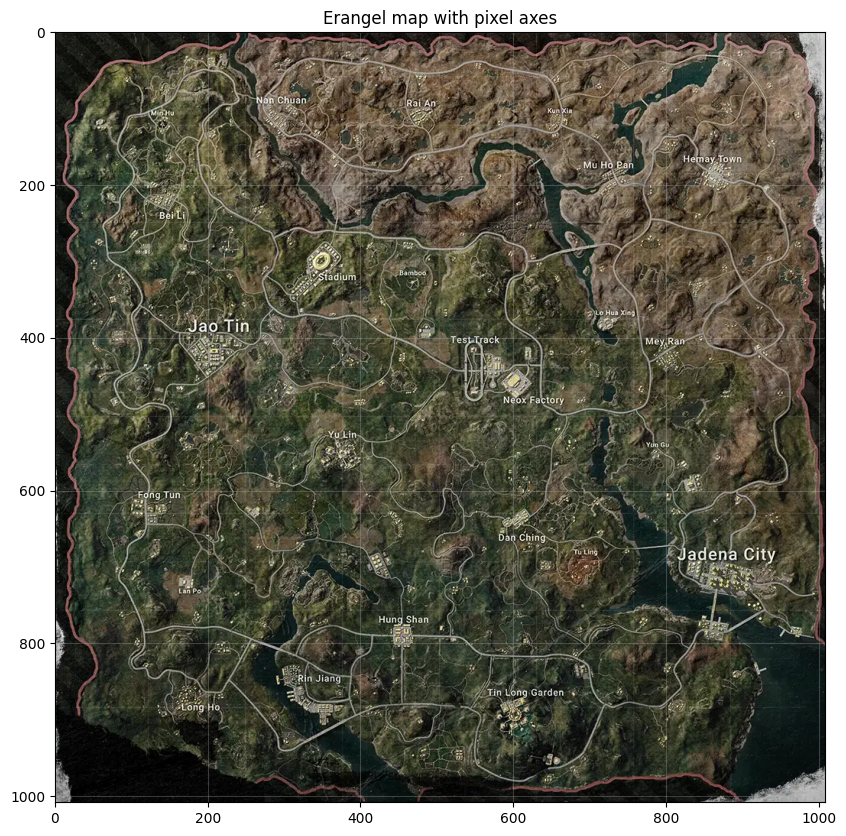

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(img, origin="upper")
plt.xlim(0, img.shape[1])
plt.ylim(img.shape[0], 0)
plt.grid(True, alpha=0.3)
plt.title("Erangel map with pixel axes")
plt.show()

In [ ]:

# # 좌표 보정용 코드
# # 에란겔 대략적인 좌표 - 수기로 책정함, 약 이정도 될 것이란 뜻
# image_points = np.array([
#     [510, 400],  # School
#     [430, 500],  # Pochinki
#     [550, 760],  # Military Base
# ], dtype=float)




In [57]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


BASE_DIR = r"C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/03_mapwise_logs_kakao+steam_20260211_20260219"
MAP_IMG_DIR = r"C:/Users/qkrtl/10th/00_Project/map_images"



MAP_IMAGES = {
    "Erangel": r"C:/Users/qkrtl/10th/00_Project/04_final/03_team_code/map_erangel.webp",
    "Miramar": r"C:/Users/qkrtl/10th/00_Project/04_final/03_team_code/map_mirarmar.webp",
    "Sanhok": r"C:/Users/qkrtl/10th/00_Project/04_final/03_team_code/map_sanhok.webp",
    "Taego": r"C:/Users/qkrtl/10th/00_Project/04_final/03_team_code/map_taego.webp",
    "Rondo": r"C:/Users/qkrtl/10th/00_Project/04_final/03_team_code/map_rondo.webp",
}

def load_map_image(map_name):
    img_fp = MAP_IMAGES[map_name]
    if not os.path.exists(img_fp):
        raise FileNotFoundError(f"맵 이미지 파일 없음: {img_fp}")
    return np.array(Image.open(img_fp))









# --------------------------------------------------
# 1) 네가 수기로 넣는 이미지 픽셀 좌표
#    순서는 반드시 GAME_CONTROL_POINTS와 같아야 함
# --------------------------------------------------
IMAGE_CONTROL_POINTS = {
    "Erangel": np.array([
        [510, 400],  # School
        [430, 500],  # Pochinki
        [550, 760],  # Military Base
    ], dtype=float),

    # "Miramar": np.array([
    #     [x1, y1],
    #     [x2, y2],
    #     [x3, y3],
    # ], dtype=float),
}

# --------------------------------------------------
# 2) 맵별 게임 좌표(대략값)
#    순서는 IMAGE_CONTROL_POINTS와 동일해야 함
#    Erangel: School, Pochinki, Military Base
# --------------------------------------------------
GAME_CONTROL_POINTS = {
    "Erangel": np.array([
        [470000, 470000],  # School 대략
        [370000, 400000],  # Pochinki 대략
        [520000, 150000],  # Military Base 대략
    ], dtype=float),

    # 추후 직접 추가
    # "Miramar": np.array([
    #     [..., ...],
    #     [..., ...],
    #     [..., ...],
    # ], dtype=float),
}

# --------------------------------------------------
# 3) 맵 이미지 파일명
# --------------------------------------------------
MAP_IMAGES = {
    "Erangel": "erangel_map.png",
    # "Miramar": "miramar_map.png",
    # "Taego": "taego_map.png",
    # "Rondo": "rondo_map.png",
}

# --------------------------------------------------
# 유틸
# --------------------------------------------------
def fit_affine(game_points, image_points):
    """
    [img_x, img_y] = A @ [game_x, game_y, 1]
    """
    game_points = np.asarray(game_points, dtype=float)
    image_points = np.asarray(image_points, dtype=float)

    X = np.hstack([game_points, np.ones((len(game_points), 1))])

    ax, *_ = np.linalg.lstsq(X, image_points[:, 0], rcond=None)
    ay, *_ = np.linalg.lstsq(X, image_points[:, 1], rcond=None)

    A = np.vstack([ax, ay])  # (2, 3)
    return A

def transform_points(points, A):
    points = np.asarray(points, dtype=float)
    X = np.hstack([points, np.ones((len(points), 1))])
    return X @ A.T

def get_affine_for_map(map_name):
    if map_name not in IMAGE_CONTROL_POINTS:
        raise KeyError(f"{map_name}의 IMAGE_CONTROL_POINTS가 없음")
    if map_name not in GAME_CONTROL_POINTS:
        raise KeyError(f"{map_name}의 GAME_CONTROL_POINTS가 없음")

    image_points = IMAGE_CONTROL_POINTS[map_name]
    game_points = GAME_CONTROL_POINTS[map_name]

    if len(image_points) != len(game_points):
        raise ValueError(f"{map_name}: image/game 기준점 개수가 다름")

    A = fit_affine(game_points, image_points)
    return A

# --------------------------------------------------
# 4) 드랍 스캐터
# --------------------------------------------------
def plot_drop_scatter_on_map_calibrated(map_name, sample_n=5000, figsize=(10, 10)):
    csv_fp = os.path.join(BASE_DIR, map_name, "LogParachuteLanding.csv")
    img_fp = os.path.join(MAP_IMG_DIR, MAP_IMAGES[map_name])

    df = pd.read_csv(csv_fp, usecols=[
        "character_location_x",
        "character_location_y"
    ]).rename(columns={
        "character_location_x": "x",
        "character_location_y": "y"
    })

    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df = df.dropna(subset=["x", "y"])

    if len(df) > sample_n:
        df = df.sample(sample_n, random_state=42)

    A = get_affine_for_map(map_name)
    pts_img = transform_points(df[["x", "y"]].values, A)

    img = mpimg.imread(img_fp)

    plt.figure(figsize=figsize)
    plt.imshow(img, origin="upper")
    plt.scatter(pts_img[:, 0], pts_img[:, 1], s=2, alpha=0.25)
    plt.title(f"{map_name} - Drop Scatter (Affine Calibrated)")
    plt.xlim(0, img.shape[1])
    plt.ylim(img.shape[0], 0)
    plt.show()

# --------------------------------------------------
# 5) 드랍 히스토그램(이미지 위 heatmap)
# --------------------------------------------------
def plot_drop_heatmap_on_map_calibrated(map_name, bins=180, chunksize=200_000, figsize=(10, 10)):
    csv_fp = os.path.join(BASE_DIR, map_name, "LogParachuteLanding.csv")
    img_fp = os.path.join(MAP_IMG_DIR, MAP_IMAGES[map_name])

    A = get_affine_for_map(map_name)

    img = mpimg.imread(img_fp)
    H = img.shape[0]
    W = img.shape[1]

    heatmap = np.zeros((bins, bins), dtype=np.float64)

    usecols = ["character_location_x", "character_location_y"]

    for chunk in pd.read_csv(csv_fp, usecols=usecols, chunksize=chunksize):
        chunk = chunk.rename(columns={
            "character_location_x": "x",
            "character_location_y": "y"
        })

        chunk["x"] = pd.to_numeric(chunk["x"], errors="coerce")
        chunk["y"] = pd.to_numeric(chunk["y"], errors="coerce")
        chunk = chunk.dropna(subset=["x", "y"])

        if chunk.empty:
            continue

        pts_img = transform_points(chunk[["x", "y"]].values, A)

        # 이미지 범위 안만 사용
        mask = (
            (pts_img[:, 0] >= 0) & (pts_img[:, 0] <= W) &
            (pts_img[:, 1] >= 0) & (pts_img[:, 1] <= H)
        )
        pts_img = pts_img[mask]

        if len(pts_img) == 0:
            continue

        h, _, _ = np.histogram2d(
            pts_img[:, 0],
            pts_img[:, 1],
            bins=[np.linspace(0, W, bins + 1), np.linspace(0, H, bins + 1)]
        )
        heatmap += h

    plt.figure(figsize=figsize)
    plt.imshow(img, origin="upper")
    plt.imshow(
        np.log1p(heatmap).T,
        extent=[0, W, H, 0],   # origin upper에 맞춤
        cmap="gray",
        alpha=0.55,
        aspect="equal"
    )
    plt.title(f"{map_name} - Drop Heatmap (Affine Calibrated)")
    plt.xlim(0, W)
    plt.ylim(H, 0)
    plt.show()

# --------------------------------------------------
# 6) 플레이어 포지션 히트맵(이미지 위)
# --------------------------------------------------
def plot_path_heatmap_on_map_calibrated(map_name, bins=220, chunksize=300_000, figsize=(10, 10)):
    csv_fp = os.path.join(BASE_DIR, map_name, "LogPlayerPosition.csv")
    img_fp = os.path.join(MAP_IMG_DIR, MAP_IMAGES[map_name])

    A = get_affine_for_map(map_name)

    img = mpimg.imread(img_fp)
    H = img.shape[0]
    W = img.shape[1]

    heatmap = np.zeros((bins, bins), dtype=np.float64)

    usecols = ["character_location_x", "character_location_y"]

    for chunk in pd.read_csv(csv_fp, usecols=usecols, chunksize=chunksize):
        chunk = chunk.rename(columns={
            "character_location_x": "x",
            "character_location_y": "y"
        })

        chunk["x"] = pd.to_numeric(chunk["x"], errors="coerce")
        chunk["y"] = pd.to_numeric(chunk["y"], errors="coerce")
        chunk = chunk.dropna(subset=["x", "y"])

        if chunk.empty:
            continue

        pts_img = transform_points(chunk[["x", "y"]].values, A)

        mask = (
            (pts_img[:, 0] >= 0) & (pts_img[:, 0] <= W) &
            (pts_img[:, 1] >= 0) & (pts_img[:, 1] <= H)
        )
        pts_img = pts_img[mask]

        if len(pts_img) == 0:
            continue

        h, _, _ = np.histogram2d(
            pts_img[:, 0],
            pts_img[:, 1],
            bins=[np.linspace(0, W, bins + 1), np.linspace(0, H, bins + 1)]
        )
        heatmap += h

    plt.figure(figsize=figsize)
    plt.imshow(img, origin="upper")
    plt.imshow(
        np.log1p(heatmap).T,
        extent=[0, W, H, 0],
        cmap="gray",
        alpha=0.60,
        aspect="equal"
    )
    plt.title(f"{map_name} - Path Heatmap (Affine Calibrated)")
    plt.xlim(0, W)
    plt.ylim(H, 0)
    plt.show()




In [58]:
plot_drop_scatter_on_map_calibrated("Erangel", sample_n=8000)
plot_drop_heatmap_on_map_calibrated("Erangel", bins=180)
plot_path_heatmap_on_map_calibrated("Erangel", bins=220)

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/qkrtl/10th/00_Project/map_images\\erangel_map.png'

맵 별 특징 분석 
> 모든 맵의 특징

In [19]:
import os
import numpy as np
import pandas as pd

# -----------------------------
# 경로 설정
# -----------------------------
BASE_DIR = r"C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/03_mapwise_logs_kakao+steam_20260211_20260219"
MAPS = ["Erangel", "Miramar", "Rondo", "Sanhok", "Taego"]

PLAYER_OUT_DIR = "player_env_outputs"
MAP_OUT_DIR = "map_env_outputs"

os.makedirs(PLAYER_OUT_DIR, exist_ok=True)
os.makedirs(MAP_OUT_DIR, exist_ok=True)

# -----------------------------
# 파라미터
# -----------------------------
GRID_SIZE = 100000    # 1km 느낌
HIGHLAND_Q = 0.75     # 상위 25%를 고지대
HOTSPOT_TOP_Q = 0.80  # 낙하 grid count 상위 20%를 hotspot

# -----------------------------
# 실제 컬럼명
# -----------------------------
COLS = {
    "LogPlayerPosition": {
        "matchId": "matchId",
        "accountId": "character_accountId",
        "elapsedTime": "elapsedTime",
        "x": "character_location_x",
        "y": "character_location_y",
        "z": "character_location_z",
        "isInBlueZone": "character_isInBlueZone",
    },
    "LogParachuteLanding": {
        "matchId": "matchId",
        "accountId": "character_accountId",
        "x": "character_location_x",
        "y": "character_location_y",
        "z": "character_location_z",
    },
    "LogVehicleRide": {
        "matchId": "matchId",
        "accountId": "character_accountId",
    }
}

# -----------------------------
# 유틸
# -----------------------------
def make_grid_id(x, y, grid_size=GRID_SIZE):
    gx = np.floor(pd.to_numeric(x, errors="coerce") / grid_size)
    gy = np.floor(pd.to_numeric(y, errors="coerce") / grid_size)
    return gx.astype("Int64").astype(str) + "_" + gy.astype("Int64").astype(str)

def shannon_entropy(counts):
    counts = pd.Series(counts)
    counts = counts[counts > 0]
    if len(counts) == 0:
        return np.nan
    p = counts / counts.sum()
    return float(-(p * np.log(p)).sum())

def euclidean(dx, dy):
    return np.sqrt(dx**2 + dy**2)

def to_bool01(series):
    """
    True/False, 1/0, 'true'/'false' 등 섞여 있어도 0/1로 변환
    """
    s = series.copy()

    if s.dtype == bool:
        return s.astype(int)

    s = s.astype(str).str.strip().str.lower()

    true_set = {"true", "1", "t", "yes", "y"}
    false_set = {"false", "0", "f", "no", "n", "nan", "none", ""}

    out = pd.Series(np.nan, index=s.index, dtype="float64")
    out[s.isin(true_set)] = 1
    out[s.isin(false_set)] = 0

    # 숫자형 문자열 혹시 섞여 있으면 한 번 더 시도
    numeric = pd.to_numeric(s, errors="coerce")
    out = out.fillna(numeric)

    return out

# -----------------------------
# 로더
# -----------------------------
def load_player_position_fast(map_dir):
    fp = os.path.join(map_dir, "LogPlayerPosition.csv")
    c = COLS["LogPlayerPosition"]

    usecols = [
        c["matchId"],
        c["accountId"],
        c["elapsedTime"],
        c["x"],
        c["y"],
        c["z"],
        c["isInBlueZone"],
    ]

    df = pd.read_csv(fp, usecols=usecols)

    df = df.rename(columns={
        c["matchId"]: "matchId",
        c["accountId"]: "accountId",
        c["elapsedTime"]: "elapsedTime",
        c["x"]: "x",
        c["y"]: "y",
        c["z"]: "z",
        c["isInBlueZone"]: "isInBlueZone",
    })

    df["matchId"] = df["matchId"].astype(str)
    df["accountId"] = df["accountId"].astype(str)
    df["elapsedTime"] = pd.to_numeric(df["elapsedTime"], errors="coerce")
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df["z"] = pd.to_numeric(df["z"], errors="coerce")
    df["isInBlueZone"] = to_bool01(df["isInBlueZone"])

    df = df.dropna(subset=["matchId", "accountId", "elapsedTime", "x", "y", "z"])
    return df


def load_parachute_landing_fast(map_dir):
    fp = os.path.join(map_dir, "LogParachuteLanding.csv")
    c = COLS["LogParachuteLanding"]

    usecols = [
        c["matchId"],
        c["accountId"],
        c["x"],
        c["y"],
        c["z"],
    ]

    df = pd.read_csv(fp, usecols=usecols)

    df = df.rename(columns={
        c["matchId"]: "matchId",
        c["accountId"]: "accountId",
        c["x"]: "x",
        c["y"]: "y",
        c["z"]: "z",
    })

    df["matchId"] = df["matchId"].astype(str)
    df["accountId"] = df["accountId"].astype(str)
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df["z"] = pd.to_numeric(df["z"], errors="coerce")

    df = df.dropna(subset=["matchId", "accountId", "x", "y"])
    return df


def load_vehicle_ride_fast(map_dir):
    fp = os.path.join(map_dir, "LogVehicleRide.csv")
    c = COLS["LogVehicleRide"]

    usecols = [
        c["matchId"],
        c["accountId"],
    ]

    df = pd.read_csv(fp, usecols=usecols)

    df = df.rename(columns={
        c["matchId"]: "matchId",
        c["accountId"]: "accountId",
    })

    df["matchId"] = df["matchId"].astype(str)
    df["accountId"] = df["accountId"].astype(str)
    df["ride_flag"] = 1

    df = df.dropna(subset=["matchId", "accountId"])
    return df

# -----------------------------
# 플레이어 단위 env 컬럼 생성
# -----------------------------
def build_player_env_features_for_map(map_name):
    map_dir = os.path.join(BASE_DIR, map_name)

    pos = load_player_position_fast(map_dir)
    land = load_parachute_landing_fast(map_dir)

    # 1) 고지대 기준
    highland_thr = pos["z"].quantile(HIGHLAND_Q)

    # 2) 낙하 hotspot grid 정의
    land["drop_grid_id"] = make_grid_id(land["x"], land["y"])
    drop_counts = land["drop_grid_id"].value_counts()

    if len(drop_counts) > 0:
        hotspot_thr = drop_counts.quantile(HOTSPOT_TOP_Q)
        hotspot_grids = set(drop_counts[drop_counts >= hotspot_thr].index.tolist())
    else:
        hotspot_grids = set()

    # 3) player path grid
    pos = pos.sort_values(["matchId", "accountId", "elapsedTime"]).copy()
    pos["grid_id"] = make_grid_id(pos["x"], pos["y"])

    rows = []

    grouped = pos.groupby(["matchId", "accountId"], sort=False)
    for (match_id, account_id), g in grouped:
        g = g.sort_values("elapsedTime").copy()

        # path_highland_ratio
        path_highland_ratio = (g["z"] >= highland_thr).mean()

        # path_terrain_roughness
        dx = g["x"].diff()
        dy = g["y"].diff()
        dz = g["z"].diff().abs()

        move_dist = euclidean(dx, dy)
        valid = move_dist.notna() & (move_dist > 0)

        if valid.sum() == 0:
            path_terrain_roughness = np.nan
        else:
            path_terrain_roughness = (dz[valid] / (move_dist[valid] + 1e-9)).mean()

        # path_hotspot_exposure
        if len(hotspot_grids) == 0:
            path_hotspot_exposure = np.nan
        else:
            path_hotspot_exposure = g["grid_id"].isin(hotspot_grids).mean()

        # bluezone_exposure_ratio
        if "isInBlueZone" in g.columns:
            bluezone_exposure_ratio = g["isInBlueZone"].mean()
        else:
            bluezone_exposure_ratio = np.nan

        rows.append({
            "mapName": map_name,
            "matchId": match_id,
            "accountId": account_id,
            "path_highland_ratio": path_highland_ratio,
            "path_terrain_roughness": path_terrain_roughness,
            "path_hotspot_exposure": path_hotspot_exposure,
            "bluezone_exposure_ratio": bluezone_exposure_ratio,
        })

    player_env = pd.DataFrame(rows)
    return player_env

# -----------------------------
# 맵 단위 summary 생성
# -----------------------------
def build_map_env_summary_for_map(map_name):
    map_dir = os.path.join(BASE_DIR, map_name)

    pos = load_player_position_fast(map_dir)
    land = load_parachute_landing_fast(map_dir)
    ride = load_vehicle_ride_fast(map_dir)

    # -----------------------------
    # map_path_highland_ratio
    # -----------------------------
    highland_thr = pos["z"].quantile(HIGHLAND_Q)
    map_path_highland_ratio = (pos["z"] >= highland_thr).mean()

    # -----------------------------
    # map_path_slope_proxy_mean
    # -----------------------------
    pos = pos.sort_values(["matchId", "accountId", "elapsedTime"]).copy()

    pos["dx"] = pos.groupby(["matchId", "accountId"])["x"].diff()
    pos["dy"] = pos.groupby(["matchId", "accountId"])["y"].diff()
    pos["dz"] = pos.groupby(["matchId", "accountId"])["z"].diff().abs()
    pos["move_dist"] = euclidean(pos["dx"], pos["dy"])

    valid = pos["move_dist"].notna() & (pos["move_dist"] > 0)

    if valid.sum() == 0:
        map_path_slope_proxy_mean = np.nan
    else:
        map_path_slope_proxy_mean = (pos.loc[valid, "dz"] / (pos.loc[valid, "move_dist"] + 1e-9)).mean()

    # -----------------------------
    # map_drop_entropy
    # -----------------------------
    land["drop_grid_id"] = make_grid_id(land["x"], land["y"])
    drop_counts = land["drop_grid_id"].value_counts()
    map_drop_entropy = shannon_entropy(drop_counts)

    # -----------------------------
    # map_vehicle_dependency_proxy
    # 플레이어 단위 ride 여부 비율
    # -----------------------------
    ride_players = (
        ride.drop_duplicates(subset=["matchId", "accountId"])
            [["matchId", "accountId"]]
            .assign(ride_flag=1)
    )

    all_players = (
        pos[["matchId", "accountId"]]
        .drop_duplicates()
        .merge(ride_players, on=["matchId", "accountId"], how="left")
    )
    all_players["ride_flag"] = all_players["ride_flag"].fillna(0)
    map_vehicle_dependency_proxy = all_players["ride_flag"].mean()

    # -----------------------------
    # map_bluezone_exposure_mean
    # player position의 isInBlueZone 직접 사용
    # -----------------------------
    bluezone_by_player = (
        pos.groupby(["matchId", "accountId"])["isInBlueZone"]
        .mean()
        .reset_index(name="bluezone_exposure_ratio")
    )
    map_bluezone_exposure_mean = bluezone_by_player["bluezone_exposure_ratio"].mean()

    summary = pd.DataFrame([{
        "mapName": map_name,
        "map_path_highland_ratio": map_path_highland_ratio,
        "map_path_slope_proxy_mean": map_path_slope_proxy_mean,
        "map_drop_entropy": map_drop_entropy,
        "map_vehicle_dependency_proxy": map_vehicle_dependency_proxy,
        "map_bluezone_exposure_mean": map_bluezone_exposure_mean
    }])

    return summary

# -----------------------------
# 실행
# -----------------------------
all_map_summaries = []

for map_name in MAPS:
    print(f"\n===== {map_name} 처리 중 =====")

    player_env = build_player_env_features_for_map(map_name)
    player_out = os.path.join(PLAYER_OUT_DIR, f"{map_name.lower()}_player_env_features.csv")
    player_env.to_csv(player_out, index=False, encoding="utf-8-sig")
    print("player saved:", player_out, player_env.shape)

    map_env = build_map_env_summary_for_map(map_name)
    map_out = os.path.join(MAP_OUT_DIR, f"{map_name.lower()}_map_env_summary.csv")
    map_env.to_csv(map_out, index=False, encoding="utf-8-sig")
    print("map saved:", map_out, map_env.shape)

    all_map_summaries.append(map_env)

all_maps = pd.concat(all_map_summaries, ignore_index=True)
all_maps.to_csv(os.path.join(MAP_OUT_DIR, "all_maps_env_summary.csv"), index=False, encoding="utf-8-sig")

print("\n전체 맵 요약")
print(all_maps)


===== Erangel 처리 중 =====
player saved: player_env_outputs\erangel_player_env_features.csv (150227, 7)
map saved: map_env_outputs\erangel_map_env_summary.csv (1, 6)

===== Miramar 처리 중 =====
player saved: player_env_outputs\miramar_player_env_features.csv (132488, 7)
map saved: map_env_outputs\miramar_map_env_summary.csv (1, 6)

===== Rondo 처리 중 =====
player saved: player_env_outputs\rondo_player_env_features.csv (123886, 7)
map saved: map_env_outputs\rondo_map_env_summary.csv (1, 6)

===== Sanhok 처리 중 =====
player saved: player_env_outputs\sanhok_player_env_features.csv (26900, 7)
map saved: map_env_outputs\sanhok_map_env_summary.csv (1, 6)

===== Taego 처리 중 =====
player saved: player_env_outputs\taego_player_env_features.csv (156875, 7)
map saved: map_env_outputs\taego_map_env_summary.csv (1, 6)

전체 맵 요약
   mapName  map_path_highland_ratio  map_path_slope_proxy_mean  \
0  Erangel                     0.25                   3.936575   
1  Miramar                     0.25               